# Fuzzy order-sorted feature (OSF) logic

## Fuzzy sort taxonomies

Sorts denote fuzzy sets. A fuzzy sort taxonomy is a fuzzy lattice (or a fuzzy partial order).

In [1]:
from fosf.parsers import parse_taxonomy
from fosf.utils.draw import notebook_display as display

In [2]:
fuzzy_taxonomy_str = """
bot < director, writer, producer, string, slasher.
director, writer, producer < person.
slasher < horror, thriller (0.5).
thriller, horror < movie.
person, string, movie < top.
"""
fuzzy_tax = parse_taxonomy(fuzzy_taxonomy_str)

`bot` (⊥) denotes the empty set, and `top` (⊤) denotes the whole domain/universe.

In [3]:
type(fuzzy_tax)

fosf.syntax.taxonomy.FuzzySortTaxonomy

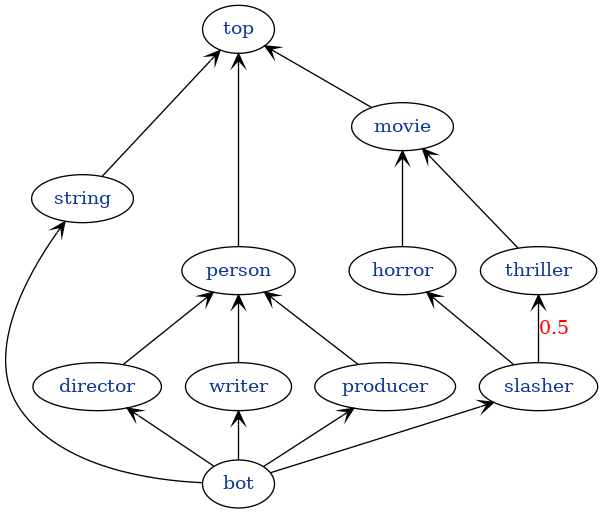

In [4]:
display(fuzzy_tax)

Greatest lower bound (GLB, or meet) computation, representing set intersection.

In [5]:
fuzzy_tax.glb("thriller", "horror")

Sort('slasher')

In [6]:
fuzzy_tax.glb("person", "producer")

Sort('producer')

In [7]:
fuzzy_tax.glb("string", "movie") # the intersection of 'string' and 'movie' is empty

Sort('bot')

Checking (fuzzy) subsumption:

In [8]:
fuzzy_tax.is_subsort("slasher", "movie")

True

In [9]:
fuzzy_tax.is_subsort("writer", "movie")

False

In [10]:
fuzzy_tax.degree("slasher", "movie")

1.0

In [11]:
fuzzy_tax.degree("slasher", "thriller")

0.5

## OSF constraints and clauses

OSF constraints are simple expressions like:

- `X:movie`, meaning that the entity denoted by `X` is of sort (type) `movie` .
- `X.directed_by = Y`, meaning that the entity denoted by `X` is directed by the entity denoted by `Y`.
- `X = Y`, meaning that the entities denoted by `X` and `Y` are the same.

Where `X` is a tag (variable), `movie` is a sort, and `directed_by` is a feature (functional attribute).

A conjunction of constraints forms an *OSF clause*.

In [12]:
from fosf.parsers import parse_clause

In [13]:
clause_str = "X:movie & X.directed_by = Y & Y:director & X.written_by = Z & Y = Z"
clause = parse_clause(clause_str)
print(f"The clause {clause} is composed of the following constraints:")
for constraint in clause:
    print(f"\t- {str(constraint):17s}` of type {type(constraint)}")

The clause X : movie  &  X.directed_by = Y  &  X.written_by = Z  &  Y : director  &  Y = Z. is composed of the following constraints:
	- Y : director     ` of type <class 'fosf.syntax.constraints.SortConstraint'>
	- Y = Z            ` of type <class 'fosf.syntax.constraints.EqualityConstraint'>
	- X.written_by = Z ` of type <class 'fosf.syntax.constraints.FeatureConstraint'>
	- X.directed_by = Y` of type <class 'fosf.syntax.constraints.FeatureConstraint'>
	- X : movie        ` of type <class 'fosf.syntax.constraints.SortConstraint'>


Graphical representation of an OSF clause:

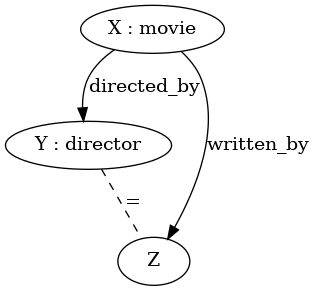

In [14]:
display(clause)

The clause represents some movie `X` directed by some `Y` (who is a director) and written by some `Z` (implicitly of sort `top`), and `Z` and `Y` are the same entity.

## OSF constraint normalization

In [15]:
from fosf.reasoning import normalize_clause

OSF clauses can be simplified into a normal form.

In [16]:
normalized_clause = normalize_clause(clause, fuzzy_tax)

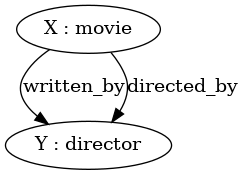

In [17]:
display(normalized_clause)

A slightly more complex example:

In [18]:
clause_str = """
X:movie       & X.title = W        & W: string &
X1 : thriller & X1.directed_by = Y & Y : director &
X2: horror    & X2.written_by  = Z & Z : person & X2.directed_by = Z
    & X = X1 & X = X2
"""
clause = parse_clause(clause_str)

Before normalization:

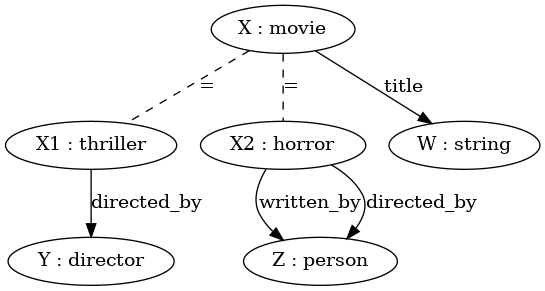

In [19]:
display(clause)

After normalization:

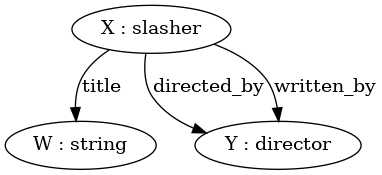

In [20]:
display(normalize_clause(clause, fuzzy_tax))

The normalization works as follows:

- Since `X`, `X1` and `X2` are supposed to be the same entity, then this entity must be a `movie`, a `thriller` and a `horror` at the same time. According to OSF logic, the sort associated with this entity must be the GLB of these three sorts, i.e., `slasher`
- Since features are *functional* and we have `X1.directed_by = Y`, `X2.directed_by = Z` and `X1 = X2`, then we must have `Y = Z`.
- Etc.

## OSF Terms

An OSF term is another type of syntactic expression in OSF logic, which generalizes first-order terms.

Every OSF term can be rewritten as an OSF clause, and (rooted solved) OSF clauses can be rewritten as (normal) OSF terms.

In [21]:
from fosf.parsers import parse_term

In [22]:
term_str = """
movie(
    directed_by -> Y:director,
    written_by -> Y,
    title -> string
)
"""
term = parse_term(term_str)
print(term)

X0 : movie(directed_by -> Y : director, written_by -> Y, title -> X1 : string)


In [23]:
term.pretty_print()

X0 : movie(
    directed_by -> Y : director
    written_by -> Y
    title -> X1 : string
)


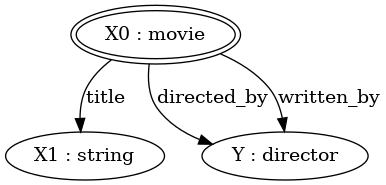

In [24]:
display(term)

Translating into an OSF clause:

In [25]:
print(term.to_clause())

X0 : movie  &  X0.directed_by = Y  &  X0.title = X1  &  X0.written_by = Y  &  X1 : string  &  Y : director.


## OSF term normalization

OSF terms with reduntant sorts/features can be normalized

In [26]:
from fosf.reasoning import normalize_term

In [27]:
term_str = """
movie(
    directed_by -> Y:director(spouse -> P:producer),
    directed_by -> Z:person(name -> string),
    written_by -> Y,
    produced_by -> P(spouse -> Y),
    title -> string
)
"""
term = parse_term(term_str)
print(term)

X0 : movie(directed_by -> Y : director(spouse -> P : producer), directed_by -> Z : person(name -> X1 : string), written_by -> Y, produced_by -> P(spouse -> Y), title -> X2 : string)


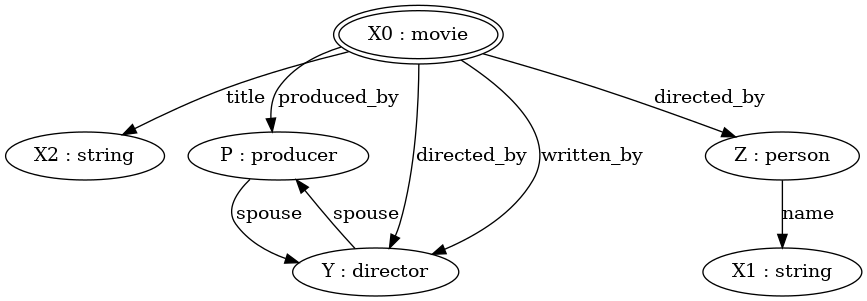

In [28]:
display(term)

In [29]:
normalized_term = normalize_term(term, fuzzy_tax)
normalized_term.pretty_print()

X0 : movie(
    directed_by -> Y : director(
        name -> X1 : string
        spouse -> P : producer(
            spouse -> Y
        )
    )
    written_by -> Y
    produced_by -> P
    title -> X2 : string
)


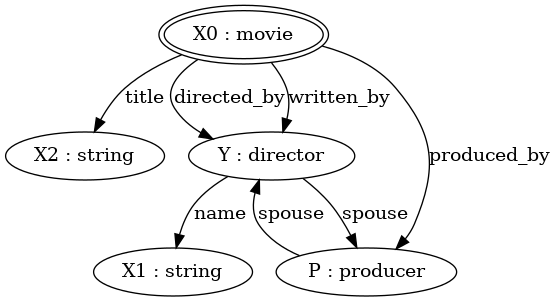

In [30]:
display(normalized_term)

## Fuzzy OSF term unification

Similarly to first-order terms, OSF terms can be unified. In fuzzy OSF logic, unification takes into account the sorts associated with the tags, and their fuzzy subsumption.

In [31]:
from fosf.syntax import NormalTerm
from fosf.reasoning import unify_terms

In [32]:
term1 = parse_term("X:thriller(directed_by -> Y:top, written_by -> Y)",
                   # If we know we are parsing a term which is in normal form, we can pass this argument
                   create_using=NormalTerm)
term1.pretty_print()

X : thriller(
    directed_by -> Y : top
    written_by -> Y
)


In [33]:
term2 = parse_term("Z:horror(directed_by -> director, written_by -> person)",
                   create_using=NormalTerm)
term2.pretty_print()

Z : horror(
    directed_by -> X0 : director
    written_by -> X1 : person
)


In [34]:
unifier, degree = unify_terms([term1, term2], fuzzy_tax, return_degree=True)
unifier.pretty_print()
print(degree)

X0 : slasher(
    directed_by -> X1 : director
    written_by -> X1
)
0.5


In fuzzy OSF logic, we can compute a unification degree as the minimum subsumption degree between the unifier and each initial term.
In this case, the unification degree is 0.5.

Visualization of how the terms are unified:

In [35]:
from fosf.utils.draw import unification_to_agraph

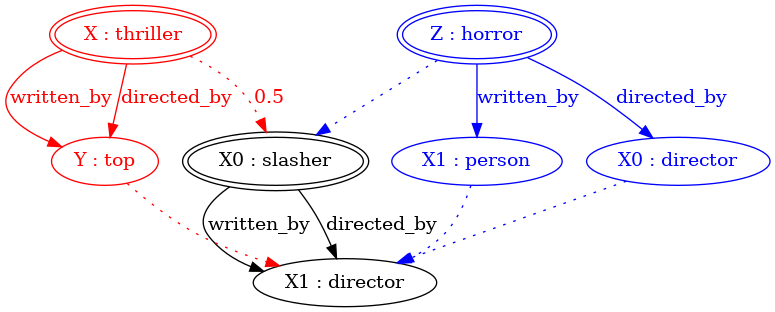

In [36]:
display(unification_to_agraph([term1, term2], fuzzy_tax))

## Sort definitions

Sort definitions allow to specify structural constraints on OSF terms. E.g.: *If X is a movie and X is directed by Y, then Y must be a director*.

An *OSF theory* is composed of a (fuzzy) sort taxonomy and a set of sort definitions. An OSF theory should satisfy *order-consistency*, that is:
if `s` is a subsort of `t`, then `s` must inherit all of `t`'s constraints.

In [37]:
from fosf.parsers import parse_theory

In [38]:
theory_str = """
# fuzzy sort taxonomy
bot < director, writer, producer, string, slasher.
director, writer, producer < person.
slasher < horror, thriller (0.5).
thriller, horror < movie.
person, string, movie < top.

# sort definitions
person   := Yp:person(spouse -> Y1:person(spouse -> Yp)).     # The spouse of a person Yp must be a person, and their spouse must be Yp
director := Yd:director(spouse -> Y2:person(spouse -> Yd)).   # director is a subsort of person, so it must inherit the spouse constraint
writer   := Yw:writer(spouse -> Y3:person(spouse -> Yw)).     # same
producer := Ypr:producer(spouse -> Y4:person(spouse -> Ypr)). # same

movie    := Ym:movie(directed_by -> Y5: director).
thriller := Yt:thriller(directed_by -> Y6: director).
horror   := Yh:horror(directed_by -> Y7: director).
slasher  := Ys:slasher(directed_by -> Y8: director).

string := Ystr:string.
"""
theory = parse_theory(theory_str)

In [39]:
sort = "horror"
definition = theory[sort]
print(f"\nThe sort '{sort}' is defined as:")
definition.pretty_print()


The sort 'horror' is defined as:
Yh : horror(
    directed_by -> Y7 : director
)


Not every sort needs to be explicitly defined as above. Instead, one can specify only the essential ones and then close the theory.

In [40]:
theory_str = """
# sort taxonomy
bot < director, writer, producer, string, slasher.
director, writer, producer < person.
slasher < horror, thriller (0.5).
thriller, horror < movie.
person, string, movie < top.

# sort definitions
person := Yp:person(spouse -> Y1:person(spouse -> Yp)).
movie  := Ym:movie(directed_by -> Y5: director).
string := Ystr:string.
"""
theory = parse_theory(theory_str, ensure_closed=True)

Now, e.g., `horror` will inherit the constraints from `movie`.

In [41]:
definition = theory[sort]
print(f"\nThe sort '{sort}' is defined as:")
definition.pretty_print()


The sort 'horror' is defined as:
Yhorror : horror(
    directed_by -> Y5 : director
)


When a term is normalized, it can be normalized according to the given theory.

In [42]:
term = parse_term("X:movie(directed_by -> top)")
normal_term = normalize_term(term, theory.taxonomy, theory)
normal_term.pretty_print()

X : movie(
    directed_by -> X0 : director
)


Without passing the theory, the term would be normalized as usual (in this case the term is already in normal form)

In [43]:
normal_term_no_theory = normalize_term(term, theory.taxonomy)
normal_term_no_theory.pretty_print()

X : movie(
    directed_by -> X0 : top
)


The constraints in the theory are checked *lazily*. E.g.: if the feature `directed_by` is not specified, then there is no need to check that its value is of the correct sort.

In [44]:
term = parse_term("X:movie")
normal_term = normalize_term(term, theory.taxonomy, theory)
normal_term.pretty_print()

X : movie


Another example:

In [45]:
term = parse_term(
    """
    movie(
        directed_by -> top(spouse -> W:top),
        written_by -> W(spouse -> director)
    )
    """
)
normal_term = normalize_term(term, theory.taxonomy, theory)
normal_term.pretty_print()

X0 : movie(
    directed_by -> X1 : director(
        spouse -> W : person(
            spouse -> X1
        )
    )
    written_by -> W
)


### Degree of satisfaction of a term with respect to a theory

In fuzzy OSF logic, a term might satisfy the constraints imposed by the theory up to some degree in (0, 1].


In [46]:
theory_str = """
# sort taxonomy
bot < thrillerdirector, horrorwriter, producer, string, slasher.
director, writer, producer < person.
thrillerdirector < director.
horrorwriter < writer.
slasher < thriller (0.5), horror.
thriller, horror < movie.
person, string, movie < top.

# sort definitions
person := Yp:person(spouse -> Y1:person(
                                    spouse -> Yp,
                                    last_name -> Yn:string),
                    last_name -> Yn).
thrillerdirector := Yt:thrillerdirector(director_of -> Y2: thriller).
horrorwriter := Yh:horrorwriter(writer_of -> Y3: horror).
movie  := Ym:movie(directed_by -> Y5: director(director_of -> Ym),
                   written_by -> Y6: writer(writer_of -> Ym)).
"""
theory = parse_theory(theory_str, ensure_closed=True)

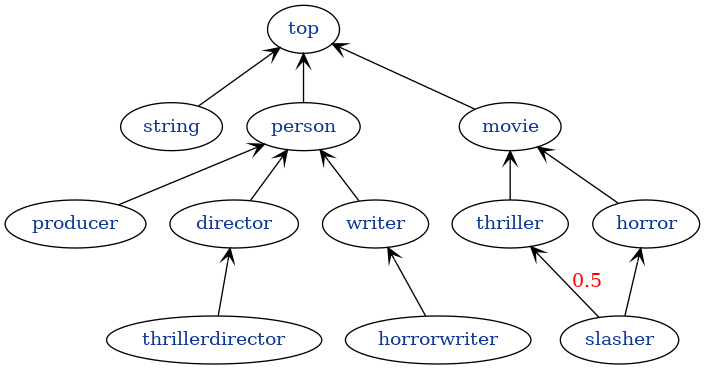

In [47]:
display(theory.taxonomy, drop="bot")

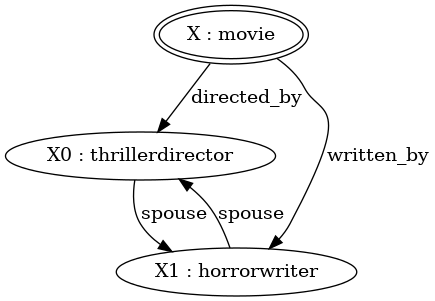

In [48]:
term_str = """
X:movie( directed_by -> X0:thrillerdirector(spouse -> X1),
       written_by -> X1:horrorwriter(spouse -> X0) )
"""
term = parse_term(term_str)
display(term)

If we normalize the term according to the theory, it turns out that it should be a `slasher`:

In [49]:
normal_term, alpha = normalize_term(term, theory.taxonomy, theory, return_degree=True)
normal_term.pretty_print()
alpha

X : slasher(
    directed_by -> X0 : thrillerdirector(
        spouse -> X1 : horrorwriter(
            spouse -> X0
            writer_of -> X
        )
        director_of -> X
    )
    written_by -> X1
)


0.5

The term satisfies the theory with degree 0.5 since, according to the theory, a `thrillerdirector` directs `thriller`s.

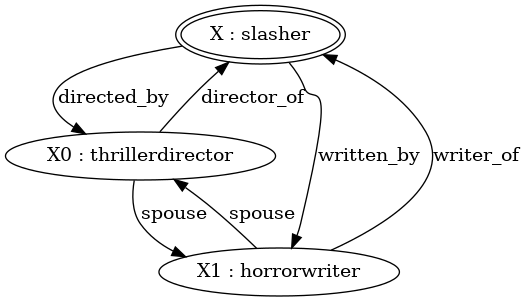

In [50]:
display(normal_term)